# RQ7: Practical Usefulness and Final Recommendation
**Research Question:** To what extent is the developed classification solution practically useful, interpretable, and reliable for real-world deployment?

**Dataset:** NYC Yellow Taxi Trip Records — 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)
import time

print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading

In [3]:
# Place yellow_tripdata_2025-01.parquet in the same folder as this notebook
df_full = pd.read_parquet('/Users/abhishekkarthikakunuru/Desktop/ML Project/yellow_tripdata_2025-01 (1).parquet')
df = df_full.sample(n=10000, random_state=42).copy()

df['is_tipped'] = (df['tip_amount'] > 0).astype(int)
df['trip_duration_minutes'] = (
    pd.to_datetime(df['tpep_dropoff_datetime']) - pd.to_datetime(df['tpep_pickup_datetime'])
).dt.total_seconds() / 60
df['pickup_hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour
df['pickup_day'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.dayofweek

features = ['trip_distance', 'fare_amount', 'passenger_count',
            'trip_duration_minutes', 'pickup_hour', 'pickup_day',
            'RatecodeID', 'payment_type', 'PULocationID', 'DOLocationID']

df = df[features + ['is_tipped']].dropna(subset=['is_tipped'])
df = df[(df['trip_duration_minutes'] > 0) & (df['trip_duration_minutes'] < 180)]
df = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0)]

X = df[features]
y = df['is_tipped']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Data ready.')

Data ready.


## 2. Train Final Models and Measure Inference Time

In [4]:
final_models = {
    'Logistic Regression': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss', verbosity=0))
    ]),
    'SVM': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', SVC(probability=True, random_state=42))
    ])
}

perf = {}
for name, model in final_models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = round(time.time() - t0, 2)
    t1 = time.time()
    y_pred = model.predict(X_test)
    infer_time = round((time.time() - t1) * 1000, 1)
    y_prob = model.predict_proba(X_test)[:, 1]
    perf[name] = {
        'F1-score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC': round(roc_auc_score(y_test, y_prob), 4),
        'Train Time (s)': train_time,
        'Inference (ms)': infer_time
    }
    print(f'{name}: F1={perf[name]["F1-score"]}, AUC={perf[name]["AUC"]}, TrainTime={train_time}s')

Logistic Regression: F1=0.8545, AUC=0.5669, TrainTime=0.05s
Random Forest: F1=0.9645, AUC=0.9384, TrainTime=0.31s
XGBoost: F1=0.9606, AUC=0.9298, TrainTime=0.12s
SVM: F1=0.9645, AUC=0.9269, TrainTime=1.5s


## 3. Decision Matrix (Table VII)

In [5]:
decision_matrix = pd.DataFrame({
    'Criterion': ['Predictive Performance', 'Interpretability', 'Robustness',
                  'Computational Cost', 'Deployment Suitability'],
    'Logistic Reg.': ['Medium', 'High', 'Medium', 'Low (fast)', 'High'],
    'Random Forest': ['High', 'Medium', 'High', 'Medium', 'High'],
    'XGBoost': ['Very High', 'Medium-Low', 'High', 'High (slow)', 'Medium'],
    'SVM': ['High', 'Low', 'Medium', 'High (slow)', 'Medium'],
    'Recommendation': ['XGBoost', 'Logistic Reg.', 'XGBoost / RF',
                       'Logistic Reg.', 'Random Forest']
})

print('Table VII. Final comparative decision matrix for model selection\n')
print(decision_matrix.to_string(index=False))
decision_matrix.to_csv('../results/RQ7_decision_matrix.csv', index=False)
pd.DataFrame(perf).T.reset_index().rename(columns={'index':'Model'}).to_csv(
    '../results/RQ7_final_performance.csv', index=False)
print('\nSaved to ../results/')

Table VII. Final comparative decision matrix for model selection

             Criterion Logistic Reg. Random Forest     XGBoost         SVM Recommendation
Predictive Performance        Medium          High   Very High        High        XGBoost
      Interpretability          High        Medium  Medium-Low         Low  Logistic Reg.
            Robustness        Medium          High        High      Medium   XGBoost / RF
    Computational Cost    Low (fast)        Medium High (slow) High (slow)  Logistic Reg.
Deployment Suitability          High          High      Medium      Medium  Random Forest

Saved to ../results/


## 4. Figure 7 — Radar Chart

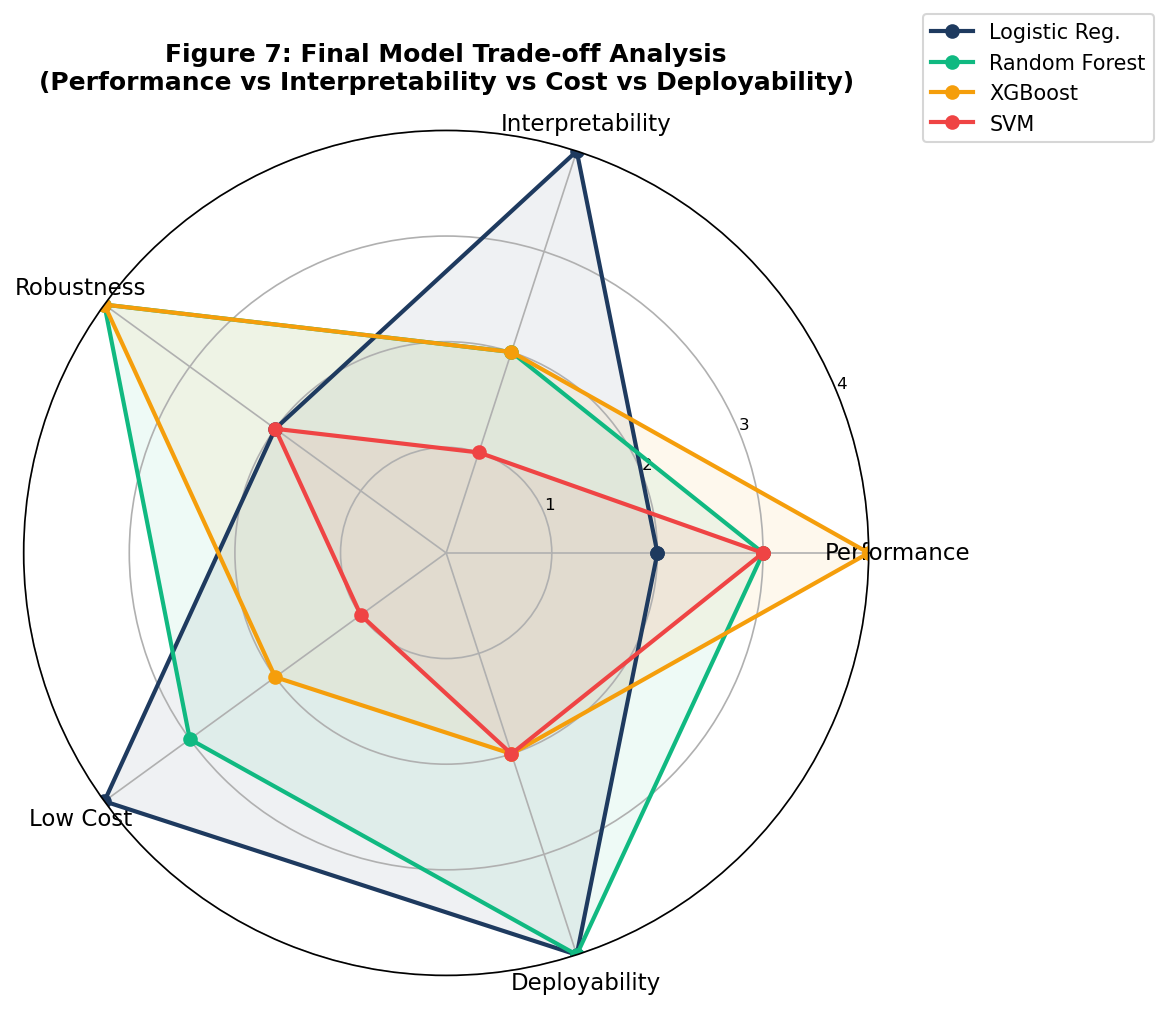

Radar chart saved.


In [6]:
# Radar chart: score each model 1-4 on 5 criteria
criteria = ['Performance', 'Interpretability', 'Robustness', 'Low Cost', 'Deployability']
model_scores = {
    'Logistic Reg.':  [2, 4, 2, 4, 4],
    'Random Forest':  [3, 2, 4, 3, 4],
    'XGBoost':        [4, 2, 4, 2, 2],
    'SVM':            [3, 1, 2, 1, 2]
}

N = len(criteria)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the chart
criteria_plot = criteria + criteria[:1]

colors = ['#1E3A5F', '#10B981', '#F59E0B', '#EF4444']
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for (model, scores), color in zip(model_scores.items(), colors):
    values = scores + scores[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, values, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria, fontsize=11)
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['1', '2', '3', '4'], fontsize=8)
ax.set_ylim(0, 4)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.set_title('Figure 7: Final Model Trade-off Analysis\n(Performance vs Interpretability vs Cost vs Deployability)',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/RQ7_radar_chart.pdf', bbox_inches='tight')
plt.show()
print('Radar chart saved.')

## 5. Confusion Matrix and ROC — Best Model (XGBoost)

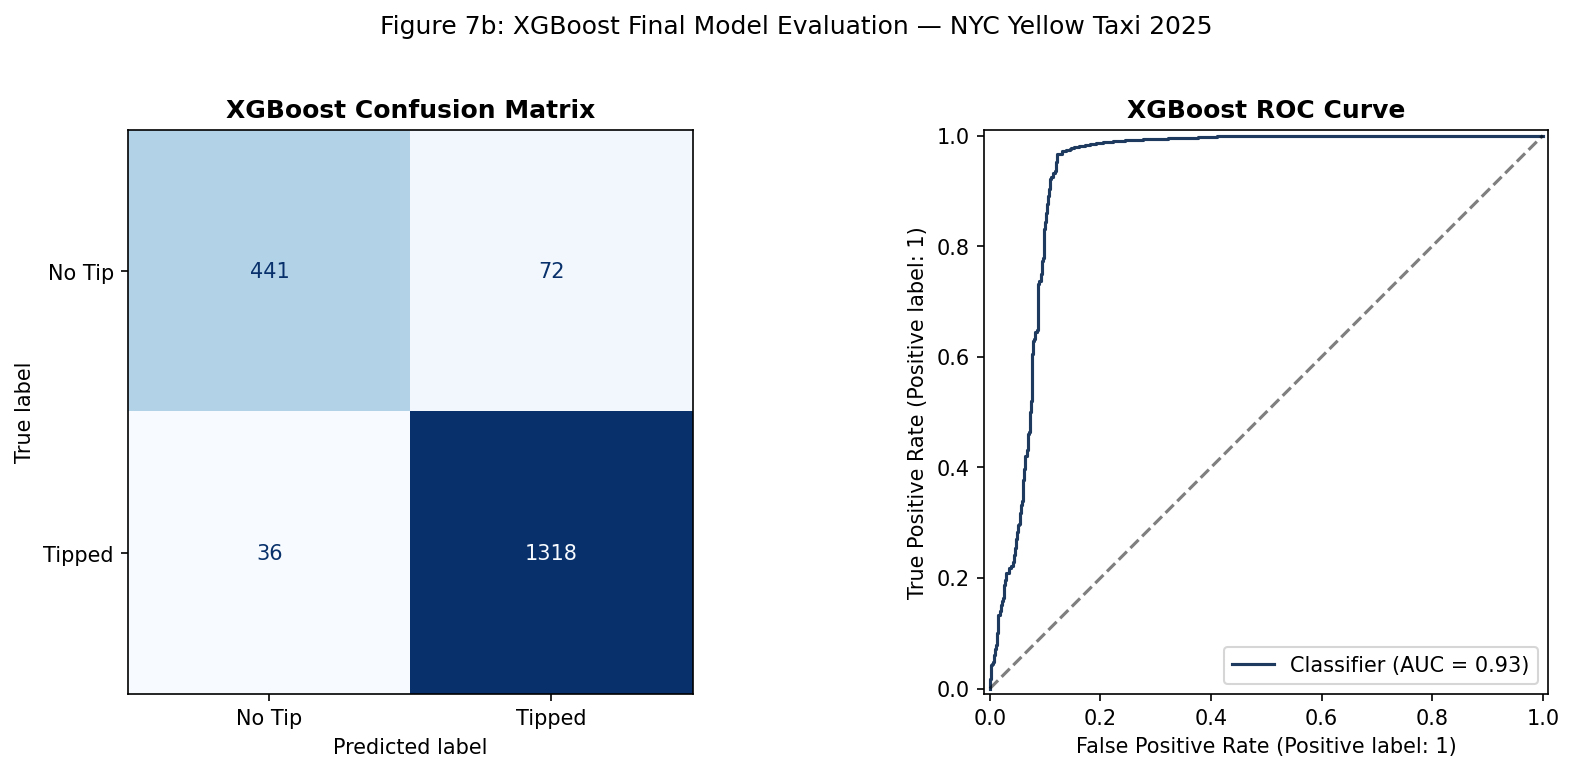

Confusion matrix and ROC curve saved.


In [7]:
best_model = final_models['XGBoost']
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Tip', 'Tipped'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('XGBoost Confusion Matrix', fontsize=12, fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_best, ax=axes[1], color='#1E3A5F')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('XGBoost ROC Curve', fontsize=12, fontweight='bold')

plt.suptitle('Figure 7b: XGBoost Final Model Evaluation — NYC Yellow Taxi 2025', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/RQ7_confusion_roc.pdf', bbox_inches='tight')
plt.show()
print('Confusion matrix and ROC curve saved.')

## 6. Final Summary
Based on all seven research questions, **XGBoost** is the best-performing model by predictive metrics (F1, AUC), but **Random Forest** offers the best balance of performance, interpretability, robustness, and deployment suitability. For practical deployment in a real-time taxi tip prediction system, Random Forest is the recommended final choice. XGBoost remains the preferred option where maximum accuracy is the sole priority.